**13/08/2026** -- Supplementary figure S5: Spatial autocorrelation of fire PM2.5 and deprivation for different neighbour distance thresholds.

Note that this uses 2000-2017 data (no imputation of SE indicators)

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [23]:
library(dplyr)
library(readr)
library(spdep)
library(ggplot2)
library(RColorBrewer)

In [3]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/data_prep.R"))
source(file.path(root, "src/deprivation_pm_bhm/pca.R"))

In [4]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_2000_2023.csv")

In [5]:
df <- read_csv(DATA_PATH)

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# Filter to <= 2022 (GDP data only available to 2022)
df <- df |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

In [7]:
# Do PCA, keep augmented dataset with PCs
df_pca_17  <- compute_pca( 
    df |> filter(year <= 2017),
    method          = "ppca",
    se_indicators   = c("stunting_pct_u5", "child_dep_pct", "edu_mean_years", "log_GDP_pc", "imp_san_access_pct"),
    n_pcs           = 5,
    scale           = TRUE,
    centre          = TRUE,
    seed            = 42,
    positive_vars   = c("stunting_pct_u5", "child_dep_pct"),
    negative_vars   = c("edu_mean_years", "log_GDP_pc", "imp_san_access_pct")
)$data

# Join PCs back onto df (helper funct)
df_17  <- prepare_analysis_data(df |> filter(year <= 2017), 
                             df_pca_17, 
                             outcome = "fire_PM25_hu", 
                             scale_y = FALSE,
                             scale_PC1 = TRUE)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(se_indicators)

  # Now:
  data %>% select(all_of(se_indicators))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


In [8]:
# Average across years
df_avg_17 <- df_17 |> 
    group_by(lon, lat, country) |>
    summarise(
        across(c(fire_PM25_hu, PC1), ~ mean(.x, na.rm = TRUE)),
        .groups = "drop"
    )

In [9]:
# Create sf_proj with point geometries
sf_proj <- sf::st_as_sf(
    df_avg_17,
    coords = c("lon","lat"), 
    crs = 4326
) %>%
    sf::st_transform(6933)

In [ ]:
# Create cols for x and y
coords <- sf::st_coordinates(sf_proj)

In [14]:
# Create neighbors at different distance bands
nb_50km <- dnearneigh(coords, 0, 50e3)
nb_100km <- dnearneigh(coords, 0, 100e3)
nb_200km <- dnearneigh(coords, 0, 200e3)
nb_350km <- dnearneigh(coords, 0, 350e3)
nb_500km <- dnearneigh(coords, 0, 500e3)

In [15]:
distances <- c(50, 100, 200, 350, 500) # distances in km (nominal for plotting)

In [16]:
# Calculate Moran's I for PM at each distance
morans_PM25 <- sapply(
    list(nb_50km, nb_100km, nb_200km, nb_350km, nb_500km),
    function(nb) {
        moran.test(df_avg_17$fire_PM25_hu, nb2listw(nb))$estimate[1]
    }
)

In [17]:
# Calculate Moran's I for PC1 at each distance
morans_PC1 <- sapply(
    list(nb_50km, nb_100km, nb_200km, nb_350km, nb_500km),
    function(nb) {
        moran.test(df_avg_17$PC1, nb2listw(nb), na.action = na.omit)$estimate[1]
    }
)

In [18]:
# df for plotting both lines
morans_i <- bind_rows(
    tibble(distance = distances,
           morans_i = morans_PM25,
           term = "Fire PM₂.₅"),
    tibble(distance = distances,
           morans_i = morans_PC1,
           term = "Deprivation")   
) %>% 
    # Make fire PM2.5 appear first in legend
    mutate(term = factor(term, levels = c("Fire PM₂.₅", "Deprivation")))

In [19]:
morans_i

distance,morans_i,term
<dbl>,<dbl>,<fct>
50,0.9830069,Fire PM₂.₅
100,0.9747625,Fire PM₂.₅
200,0.9591782,Fire PM₂.₅
350,0.9309397,Fire PM₂.₅
500,0.8966332,Fire PM₂.₅
50,0.9763016,Deprivation
100,0.9546840,Deprivation
200,0.9155832,Deprivation
350,0.8609865,Deprivation


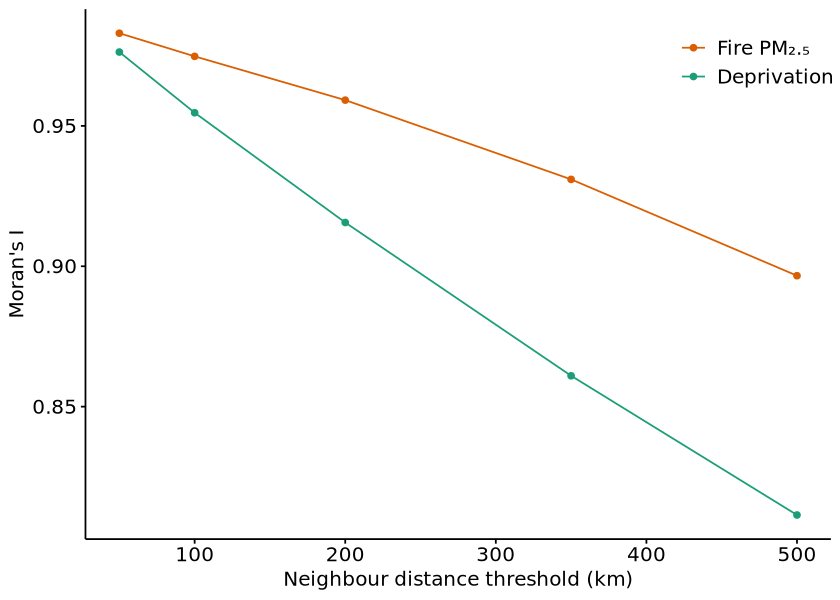

In [24]:
options(repr.plot.height = 5, repr.plot.width = 7)
ggplot(
    morans_i,
    aes(x = distance, y = morans_i, color = term, fill = term)
) +
    geom_point() +
    geom_line() + 
    # scale_color_brewer(palette = "Dark2") +
    scale_color_manual(
            values = setNames(
            brewer.pal(8, "Dark2")[c(2, 1)],   # orange first, green second
            levels(morans_i$term)
        )
    ) +
    labs(
        x = "Neighbour distance threshold (km)",
        y = "Moran's I",
    ) + 
    theme_minimal() +
    theme(
        legend.title = element_blank(),
        legend.text = element_text(color = "black", size = 12),
        legend.position = "inside",
        legend.position.inside = c(0.9, 0.9),
        axis.ticks = element_line(color = "black"),
        panel.grid.major = element_blank(),         
        panel.grid.minor = element_blank(),         
        axis.line = element_line(colour = "black"),
        axis.title = element_text(color = "black", size = 12),
        axis.text = element_text(color = "black", size = 12),
    )

In [25]:
ggsave(
    filename    = file.path(root, "paper_results/figures/supplementary_fig_S5.png"),
    width       = 7,
    height      = 5,
    dpi         = 450,
    bg          = "white"
)